# Notebook For Computing Continual Learning Metrics

In [1]:
import torch
import torchvision
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import os, sys, math
from copy import deepcopy
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import click
import glob
import h5py
import gc

from EIANN import Network
from EIANN.utils import (read_from_yaml, write_to_yaml, analyze_simple_EIANN_epoch_loss_and_accuracy, \
    sort_by_val_history, recompute_validation_loss_and_accuracy, check_equilibration_dynamics, compute_test_loss_and_accuracy, \
    recompute_train_loss_and_accuracy, compute_test_loss_and_accuracy_history, sort_by_class_averaged_val_output,
                         get_binned_mean_population_attribute_history_dict)
from EIANN.plot import (plot_batch_accuracy, plot_train_loss_history, plot_validate_loss_history, plot_receptive_fields,
                        plot_representation_metrics)
from nested.utils import Context, str_to_bool
from nested.optimize_utils import update_source_contexts
from EIANN.optimize.network_config_updates import *
import EIANN.utils as utils

%load_ext autoreload
%autoreload 2

In [2]:
def get_split_mnist_dataset(data_dir, num_splits):
    tensor_flatten = T.Compose([T.ToTensor(), T.Lambda(torch.flatten)])
    MNIST_train_dataset = torchvision.datasets.MNIST(root=data_dir, train=True, download=False, transform=tensor_flatten)
    MNIST_test_dataset = torchvision.datasets.MNIST(root=data_dir, train=False, download=False, transform=tensor_flatten)

    # split data
    num_classes = len(MNIST_test_dataset.classes)
    classes_per_task = num_classes // num_splits

    labels_in_tasks = [list(range(t, min(num_classes, t+classes_per_task))) for t in range(0, num_classes, classes_per_task)]
    
    train_datasets = [[] for _ in range(len(labels_in_tasks))]
    val_datasets = [[] for _ in range(len(labels_in_tasks))]
    test_datasets = [[] for _ in range(len(labels_in_tasks))]
    full_test_dataset = []

    for idx, (data, label) in enumerate(MNIST_train_dataset): 
        target = torch.eye(num_classes)[label]
        task_membership = [i for i, labels in enumerate(labels_in_tasks) if label in labels][0]
        
        if idx < 50000:
            train_datasets[task_membership].append((idx, data, target))
        else:
            val_datasets[task_membership].append((idx, data, target))

    for idx, (data, label) in enumerate(MNIST_test_dataset):
        target = torch.eye(num_classes)[label]
        task_membership = [i for i, labels in enumerate(labels_in_tasks) if label in labels][0]

        full_test_dataset.append((idx, data, target))
        test_datasets[task_membership].append((idx, data, target))

    train_dataloaders = []
    val_dataloaders = []
    test_dataloaders = []

    data_generator = torch.Generator()

    # put data into dataloaders
    for task_train, task_val, task_test in zip(train_datasets, val_datasets, test_datasets):
        train_dataloaders.append(torch.utils.data.DataLoader(task_train, shuffle=True, generator=data_generator))
        val_dataloaders.append(torch.utils.data.DataLoader(task_val, batch_size=len(task_val), shuffle=False))
        test_dataloaders.append(torch.utils.data.DataLoader(task_test, batch_size=len(task_test), shuffle=False))

    full_test_dataloader = torch.utils.data.DataLoader(full_test_dataset, batch_size=len(full_test_dataset), shuffle=False)

    return train_dataloaders, val_dataloaders, test_dataloaders, full_test_dataloader

### Get Standard CL Metrics 

In [3]:
# model_folder_path = '../data/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G'
# config_file_path = '../optimize/optimize_config/MNIST_CL/20240923_nested_optimize_EIANN_2_hidden_CL_mnist_van_bp_relu_SGD_config_G.yaml'
model_folder_path = '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A'
config_file_path = '../optimize/optimize_config/MNIST_CL/20260203_nested_optimize_EIANN_2_hidden_CL_mnist_5_tasks_BTSP_ELR_config_A.yaml'

data_dir = '../data/datasets/MNIST_data'
num_splits = 5
task = 'split_mnist'

In [4]:
seeds = [seed for seed in os.listdir(model_folder_path) if os.path.isdir(os.path.join(model_folder_path, seed))]
subtask_accuracy_per_seed = []
overall_accuracy_per_seed = []

task_test_loaders = full_test_loader = None

if task == 'split_mnist':
    task_train_dataloaders, task_val_dataloaders, task_test_loaders, full_test_loader =  get_split_mnist_dataset(data_dir, num_splits)


for seed in seeds:
    print(f'Computing Metrics for Seed {seed}')
    phase_weight_paths = sorted(glob.glob(os.path.join(model_folder_path, seed, '*.pkl')))
    seed_accuracies = []

    for weight_path in phase_weight_paths:
        
        network = utils.load_network(weight_path)
        phase_accuracies = []
        for i, test_loader in enumerate(task_test_loaders):
            test_loss, test_accuracy = compute_test_loss_and_accuracy(network, test_loader)
            phase_accuracies.append(float(test_accuracy))

        seed_accuracies.append(phase_accuracies)

    full_test_loss, full_test_accuracy = compute_test_loss_and_accuracy(network, full_test_loader)
    
    subtask_accuracy_per_seed.append(seed_accuracies)
    overall_accuracy_per_seed.append(float(full_test_accuracy))
    print(seed_accuracies)


subtask_accuracy_per_seed = np.array(subtask_accuracy_per_seed)
overall_accuracy_per_seed = np.array(overall_accuracy_per_seed)

on_task_accuracies = np.zeros((len(seeds),))
accuracies = np.zeros((len(seeds),))
backward_transfers = np.zeros((len(seeds),))
forward_transfers = np.zeros((len(seeds),))

# get CL metrics as outlined here: https://arxiv.org/abs/1810.13166
for i in range(num_splits):
    for j in range(num_splits):
        if i == j:
            on_task_accuracies += subtask_accuracy_per_seed[:, i, j]
        if i >= j:
            accuracies += subtask_accuracy_per_seed[:, i, j]
        if i > j:
            backward_transfers += (subtask_accuracy_per_seed[:, i, j] - subtask_accuracy_per_seed[:, j, j])
        if i < j:
            forward_transfers += subtask_accuracy_per_seed[:, i, j]

on_task_accuracies /= (num_splits)
accuracies /= (num_splits * (num_splits + 1) / 2)
backward_transfers /= (num_splits * (num_splits - 1) / 2)
forward_transfers /= (num_splits * (num_splits - 1) / 2)

print(f'On Task Accuracies: {on_task_accuracies}')
print(f'Accuracies: {accuracies}')
print(f'Backward Transfers: {backward_transfers}')
print(f'Forward Transfers: {forward_transfers}')

print(subtask_accuracy_per_seed)


Computing Metrics for Seed 66049
Loading network from '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A/66049/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A_phase0_66049_257_btsp_elr.pkl'
Network successfully loaded from '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A/66049/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A_phase0_66049_257_btsp_elr.pkl'
Loading network from '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A/66049/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A_phase1_66049_257_btsp_elr.pkl'
Network successfully loaded from '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A/66049/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A_phase1_66049_257_btsp_elr.pkl'
Loading network from '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A/66049/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A_phase2_66049_257_btsp_elr.pkl'
Network successfully loaded from '../data/20260203_EIANN_2_hidden_CL_mnist_BTSP_ELR_config_A/66049

In [7]:
n_tasks = subtask_accuracy_per_seed.shape[-1]
running_accuracy = (subtask_accuracy_per_seed * np.tri(n_tasks)).sum(-1) / np.arange(1, n_tasks+1)
average_running_accuracy = running_accuracy.mean(0)
std_running_accuracy = running_accuracy.std(0)

average_running_accuracy, std_running_accuracy

(array([99.90543365, 95.17892456, 81.07303874, 77.63621426, 55.4342907 ]),
 array([0., 0., 0., 0., 0.]))

In [8]:
# BP #
bp_average_running_accuracy = np.array([99.92907715, 49.5204149 , 33.347463  , 14.64355094, 19.18708934])
bp_average_running_std = np.array([0.02364349, 0.13255937, 0.01559247, 1.45375452, 0.24810963])
bp_average_running_std = np.array([0., 0., 0., 0., 0.])


# BTSP #
btsp_average_running_accuracy = np.array([99.90543365, 95.17892456, 81.07303874, 77.63621426, 55.4342907])
btsp_average_running_std = np.array([0., 0., 0., 0., 0.])

n_tasks = 5


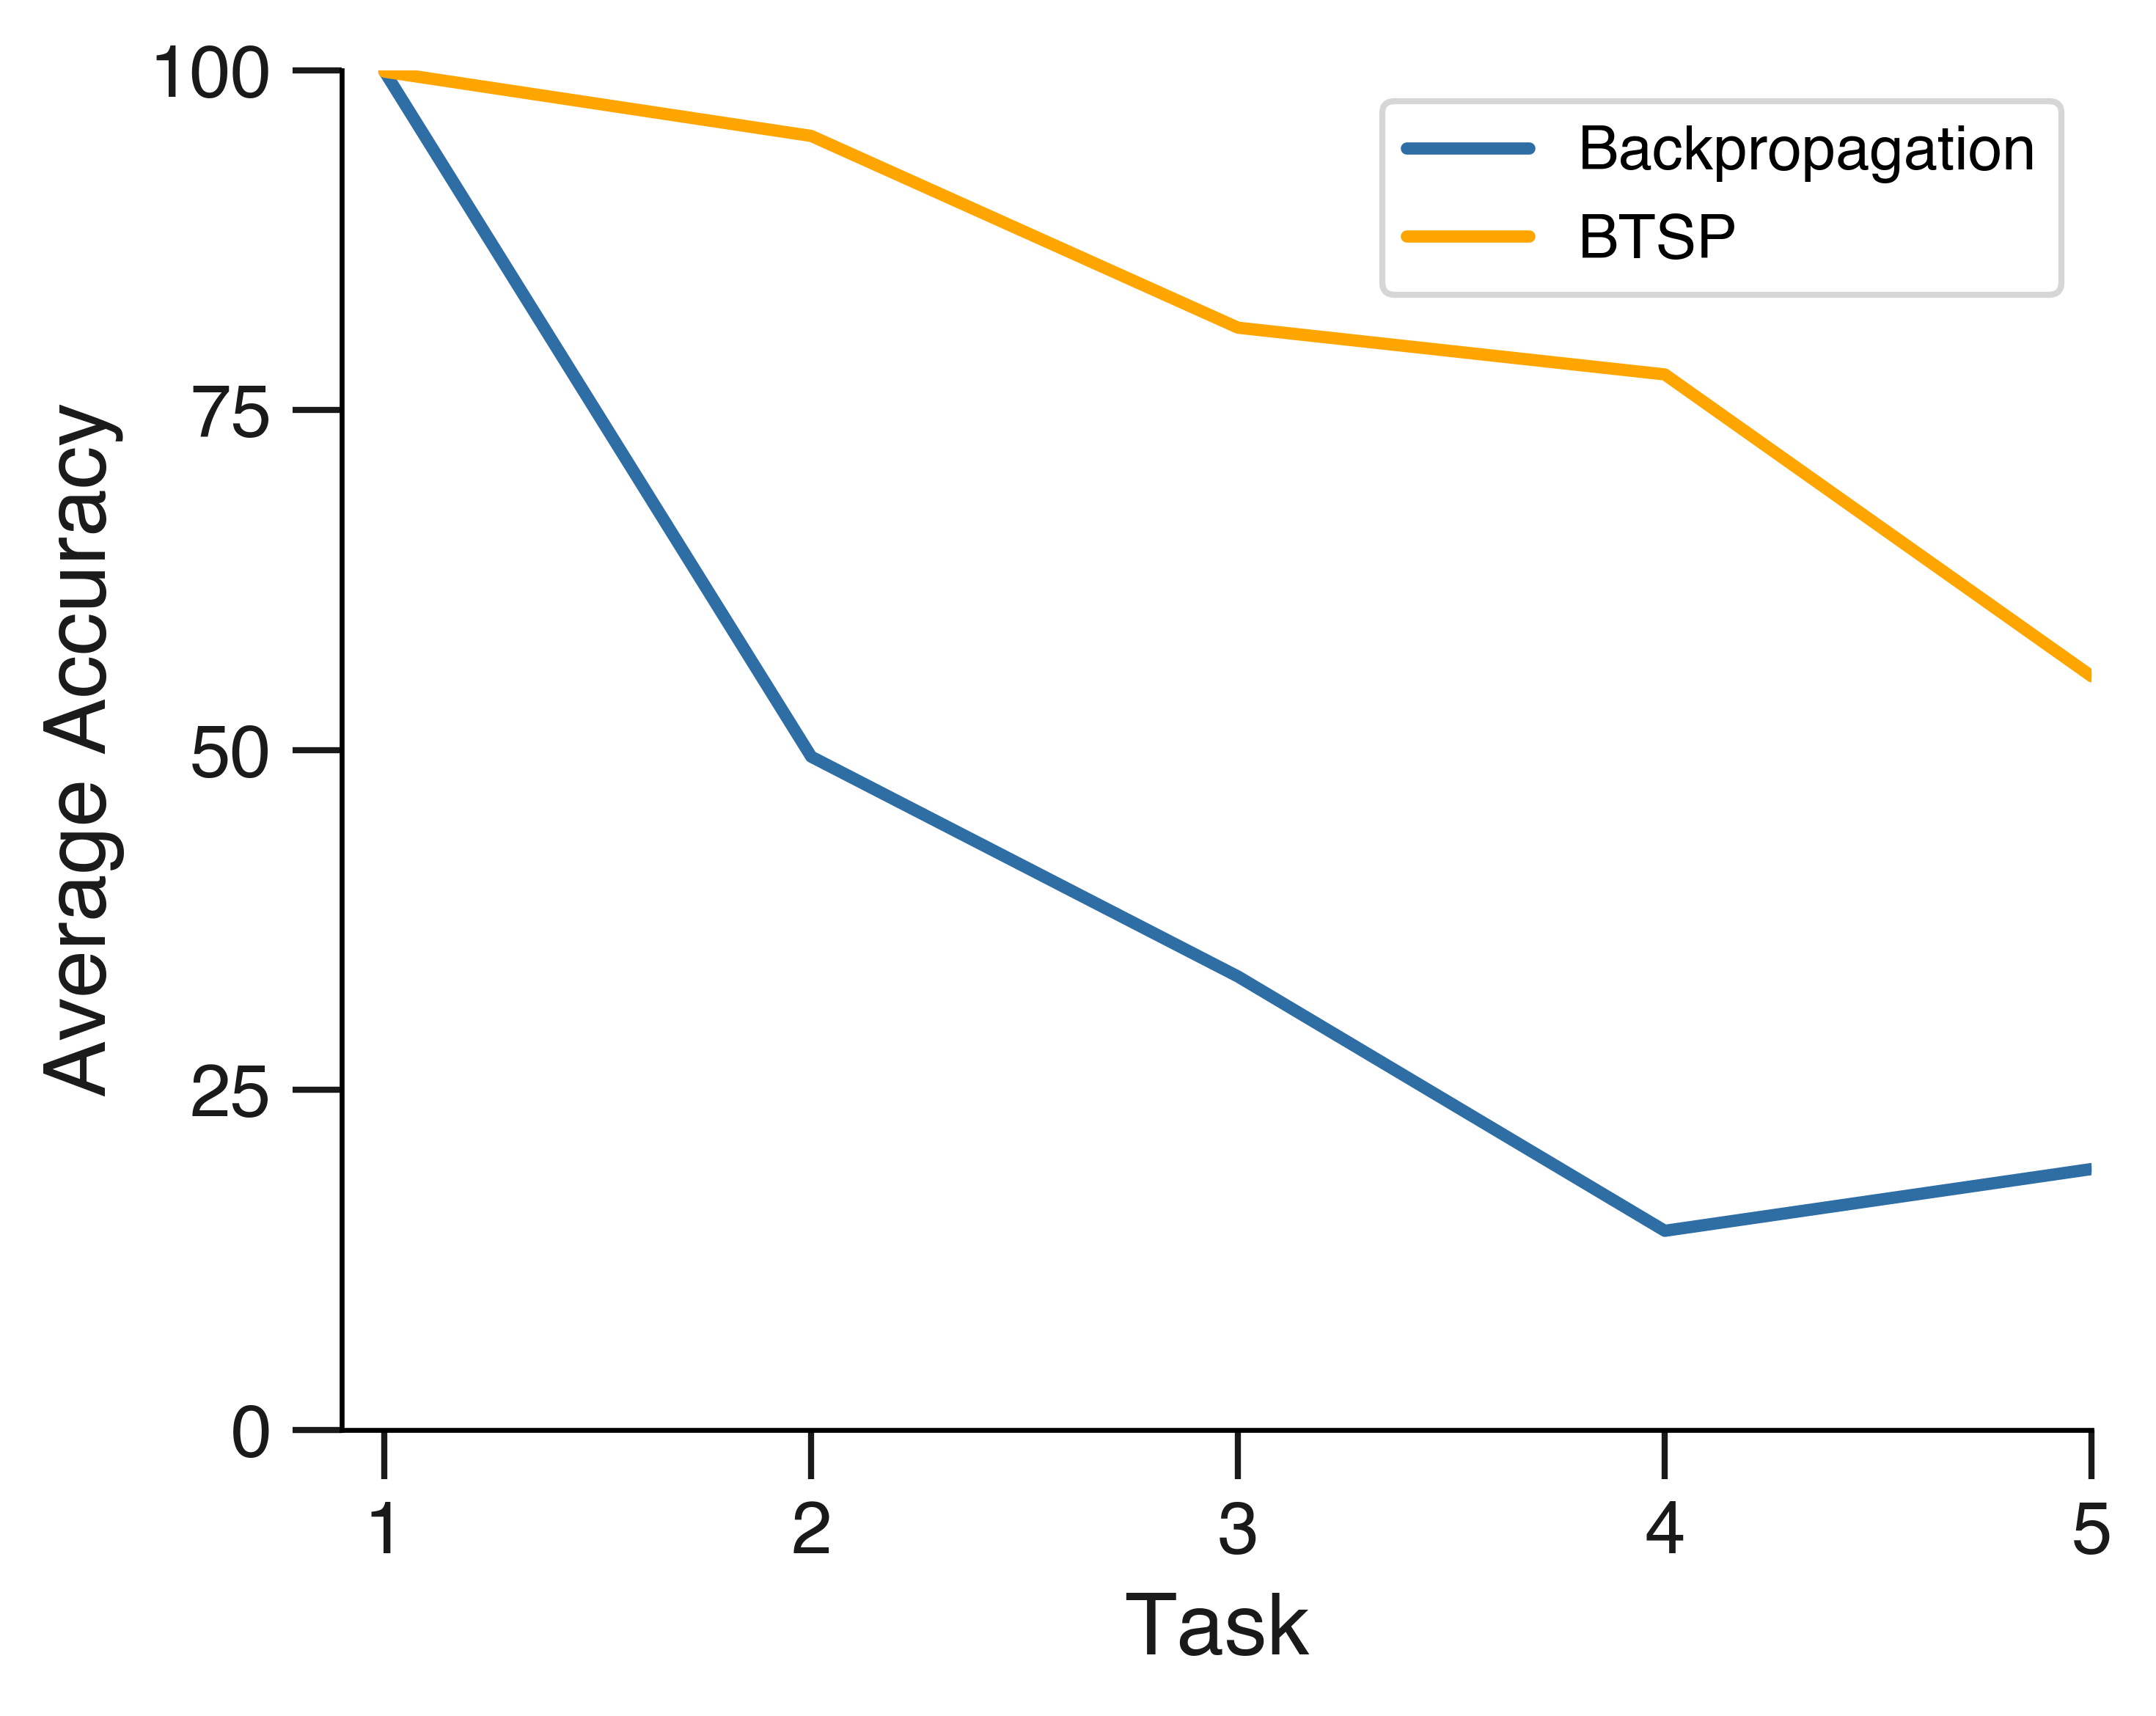

In [10]:
# Keep text as real text objects (not outlines) so labels stay editable in Illustrator.
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]


INK = "#1a1a1a"
MUTED = "#6b6b6b"

fig, ax = plt.subplots(figsize=(5.0, 4.0), dpi=600)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(1, n_tasks+1)

ax.plot(x, bp_average_running_accuracy, color='#2f6ea5', linewidth=2.0, solid_capstyle="round", solid_joinstyle="round", label='Backpropagation')
ax.fill_between(x, bp_average_running_accuracy - bp_average_running_std, bp_average_running_accuracy + bp_average_running_std, color='#2f6ea5', alpha=0.3)

ax.plot(x, btsp_average_running_accuracy, color='orange', linewidth=2.0, solid_capstyle="round", solid_joinstyle="round", label='BTSP')
ax.fill_between(x, btsp_average_running_accuracy - btsp_average_running_std, btsp_average_running_accuracy + btsp_average_running_std, color='orange', alpha=0.3)


ax.set_xlim(0.9, 5)
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_yticks([0, 25, 50, 75, 100])

ax.set_xlabel("Task", fontsize=14, color=INK, labelpad=4)
ax.set_ylabel("Average Accuracy", fontsize=14, color=INK, labelpad=4)
plt.legend() 


# Recessive frame: only left and bottom, thin, offset from the data.
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.tick_params(axis="both", which="both", length=8, width=1.0,
               color=INK, labelsize=12, labelcolor=INK)

fig.tight_layout()
fig.savefig("../data/cl_plots/average_accuracy.svg", format="svg", transparent=True)
plt.show()


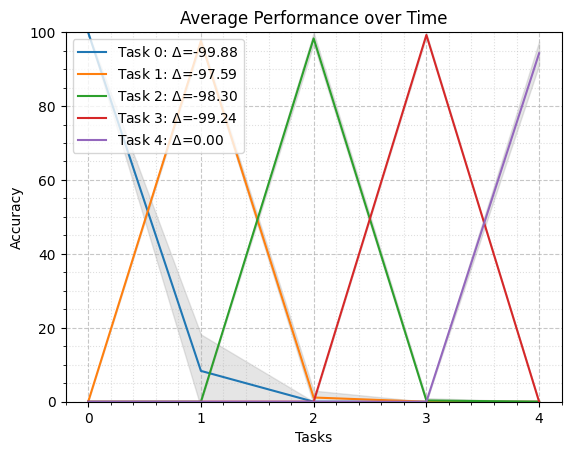

In [42]:
average_subtask_accuracy = subtask_accuracy_per_seed.mean(0).T
std = subtask_accuracy_per_seed.std(0).T

delta_accuracies = [average_subtask_accuracy[-1][i] - average_subtask_accuracy[i][i] for i in range(len(average_subtask_accuracy))]
delta_accuracies, average_subtask_accuracy

t = list(range(len(average_subtask_accuracy)))

# Plot each line
for i, line in enumerate(average_subtask_accuracy):
    plt.plot(t, line, label=f'Task {i}: $\Delta$={delta_accuracies[i]:.2f}')
    plt.fill_between(t, line - std[i], line + std[i], alpha=0.2, color='gray')

plt.xlabel('Tasks')
plt.ylabel('Accuracy')
plt.title('Average Performance over Time')
plt.xticks(t)
plt.grid(True, linestyle='--', alpha=0.7)
plt.minorticks_on()  # enable minor ticks
plt.grid(which='minor', linestyle=':', alpha=0.4)  # lighter, denser grid

plt.ylim(0, 100)
plt.legend()
plt.show()

## Fisher Information Analysis

In [38]:
phase0_weights = '../data/20251229_EIANN_2_hidden_mnist_BTSP_config_6L/66050/20251229_EIANN_2_hidden_mnist_BTSP_config_6L_phase0_66050_258.pkl'
phase0_network = utils.load_network(phase0_weights)

phase1_weights = '../data/20251229_EIANN_2_hidden_mnist_BTSP_config_6L/66050/20251229_EIANN_2_hidden_mnist_BTSP_config_6L_phase1_66050_258.pkl'
phase1_network = utils.load_network(phase1_weights)

# phase0_weights = '../data/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G/66050/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G_phase1_66050_258_van_bp.pkl'
# phase0_network = utils.load_network(phase0_weights)

# phase1_weights = '../data/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G/66050/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G_phase2_66050_258_van_bp.pkl'
# phase1_network = utils.load_network(phase1_weights)

Loading network from '../data/20251229_EIANN_2_hidden_mnist_BTSP_config_6L/66050/20251229_EIANN_2_hidden_mnist_BTSP_config_6L_phase0_66050_258.pkl'
Network successfully loaded from '../data/20251229_EIANN_2_hidden_mnist_BTSP_config_6L/66050/20251229_EIANN_2_hidden_mnist_BTSP_config_6L_phase0_66050_258.pkl'
Loading network from '../data/20251229_EIANN_2_hidden_mnist_BTSP_config_6L/66050/20251229_EIANN_2_hidden_mnist_BTSP_config_6L_phase1_66050_258.pkl'
Network successfully loaded from '../data/20251229_EIANN_2_hidden_mnist_BTSP_config_6L/66050/20251229_EIANN_2_hidden_mnist_BTSP_config_6L_phase1_66050_258.pkl'


In [39]:
def compute_fisher_diagonal(network, train_dataloader):
    fisher = {}
    for n,p in network.named_parameters():
        p.requires_grad = True # allow for gradients to pass through for fisher
        fisher[n] = torch.zeros_like(p)

    for _, sample_data, sample_target in train_dataloader:
        network.zero_grad()

        sample_target = torch.argmax(sample_target, -1).squeeze()
        
        output = network.forward(sample_data, no_grad=False)
        loss = F.nll_loss(output, sample_target)

        loss.backward()

        for n, p in network.named_parameters():
            if p.requires_grad == True:
                fisher[n] += p.grad ** 2 / len(train_dataloader.dataset)
    return fisher

phase0_fisher = compute_fisher_diagonal(phase0_network, task_train_dataloaders[0])

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [35]:
delta_weights = {}
for n,p in phase1_network.named_parameters():
    delta_weights[n] = p - phase0_network.get_parameter(n)

In [36]:
all_delta_weights = torch.cat([t.flatten() for t in delta_weights.values()]).detach().numpy()
all_fisher_weights = torch.cat([t.flatten() for t in phase0_fisher.values()]).detach().numpy()

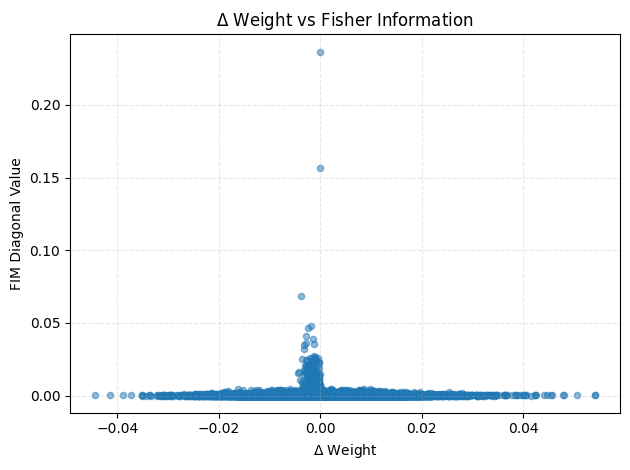

In [37]:
plt.scatter(all_delta_weights, all_fisher_weights, alpha=0.5, s=20)

plt.xlabel("$\Delta$ Weight")
plt.ylabel("FIM Diagonal Value")
plt.title("$\Delta$ Weight vs Fisher Information")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()